In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
salary_data = pd.read_csv('dataset.csv')
salary_data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [21]:
salary_data.shape

(375, 6)

In [22]:
salary_data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [23]:
# Renameing the columns as they are not in standards
salary_data.columns = ['Age', 'Gender', 'Degree', 'Job_title', 'Experience_years', 'Salary']

In [24]:
salary_data.head()

,Age,Gender,Degree,Job_title,Experience_years,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [25]:
salary_data.dtypes
# gender, degree and job_title are categorical columns.

Age                 float64
Gender                  str
Degree                  str
Job_title               str
Experience_years    float64
Salary              float64
dtype: object

In [26]:
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               373 non-null    float64
 1   Gender            373 non-null    str    
 2   Degree            373 non-null    str    
 3   Job_title         373 non-null    str    
 4   Experience_years  373 non-null    float64
 5   Salary            373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [27]:
# check for duplicate records
salary_data[salary_data.duplicated()]

,Age,Gender,Degree,Job_title,Experience_years,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
255,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
256,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
257,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [28]:
salary_data[salary_data.duplicated()].shape

# It means 50 records are duplicated.

(50, 6)

In [ ]:
# dropping duplicated rows
new_salary_data = salary_data.drop_duplicates(keep='first')

# first means it will keep the first record and rest duplicate record will be deleted

In [30]:
new_salary_data.shape

(325, 6)

In [31]:
# check if there are any null values
new_salary_data.isnull().sum()

Age                 1
Gender              1
Degree              1
Job_title           1
Experience_years    1
Salary              1
dtype: int64

In [33]:
# now drop these null/missing values
new_salary_data.dropna(how='any', inplace=True)

# inplace true means we are removing from the same dataset. So there is no need to create separate dataframe.

In [34]:
new_salary_data.shape

(324, 6)

In [36]:
# Data Exploration and Visualization

# Statistics of numerical columns
new_salary_data.describe()

# so there are 3 numerical columns. 

,Age,Experience_years,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [40]:
# Corelation among numerial columns
corr = new_salary_data[['Age', 'Experience_years', 'Salary']].corr()
corr

,Age,Experience_years,Salary
Age,1.000000,0.979192,0.916543
Experience_years,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


    97% means as age inc exp also increases. So there is a good corelation between all of these. 

<Axes: >

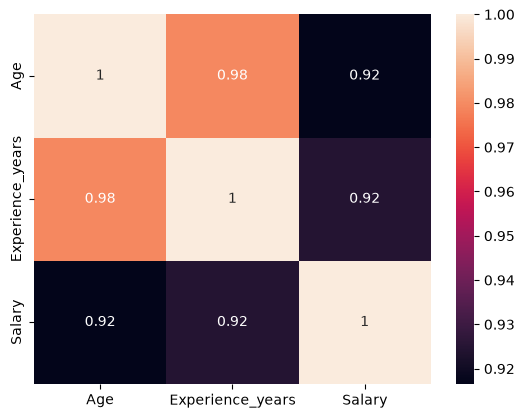

In [ ]:
sns.heatmap(corr, annot= True)
# annot true means display the values also.
# yellow and orange colors are highly co-related

In [42]:
# Data Visualization
new_salary_data['Degree'].value_counts()

Degree
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

<Axes: xlabel='Degree'>

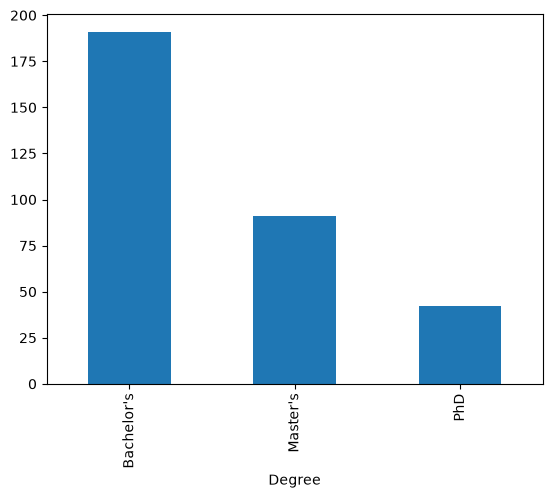

In [43]:
new_salary_data['Degree'].value_counts().plot(kind = 'bar')


In [ ]:
new_salary_data['Job_title'].value_counts()
# there are 174 unique categories in job title so it is difficult to project it. 

Job_title
Director of Operations           9
Director of Marketing            8
Senior Marketing Manager         8
Senior Project Manager           7
Senior Data Scientist            6
                                ..
Junior Research Scientist        1
Senior HR Specialist             1
Junior Operations Coordinator    1
Director of HR                   1
Junior Financial Advisor         1
Name: count, Length: 174, dtype: int64

In [46]:
new_salary_data['Job_title'].unique()

<StringArray>
[            'Software Engineer',                  'Data Analyst',
                'Senior Manager',               'Sales Associate',
                      'Director',             'Marketing Analyst',
               'Product Manager',                 'Sales Manager',
         'Marketing Coordinator',              'Senior Scientist',
 ...
     'Senior Software Architect',     'Junior Research Scientist',
      'Senior Financial Manager',          'Senior HR Specialist',
          'Senior Data Engineer', 'Junior Operations Coordinator',
                'Director of HR', 'Senior Operations Coordinator',
      'Junior Financial Advisor',       'Director of Engineering']
Length: 174, dtype: str

<Axes: ylabel='Gender'>

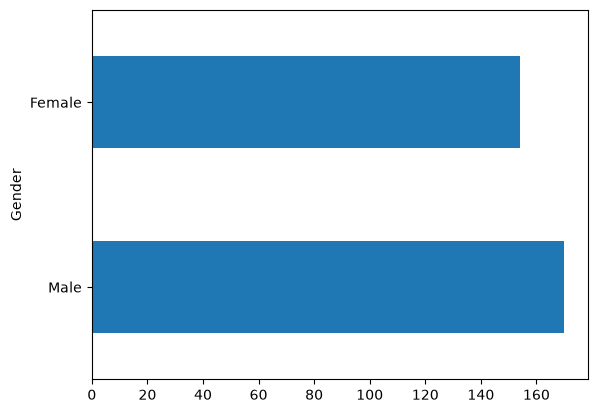

In [47]:
new_salary_data['Gender'].value_counts().plot(kind = 'barh')

### For numerical values we plot either histo or box plot

<Axes: ylabel='Frequency'>

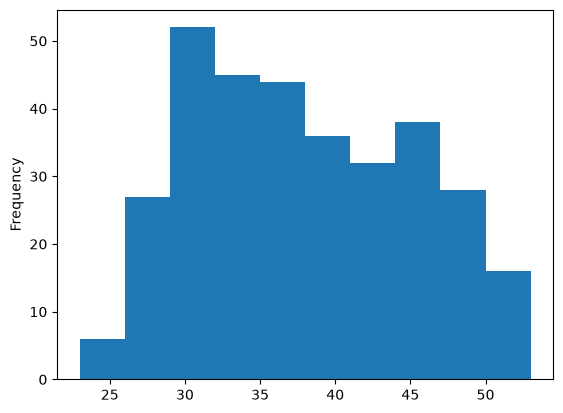

In [49]:
# new_salary_data.Age.plot(kind = 'hist')  
# or 
new_salary_data['Age'].plot(kind='hist')

<Axes: >

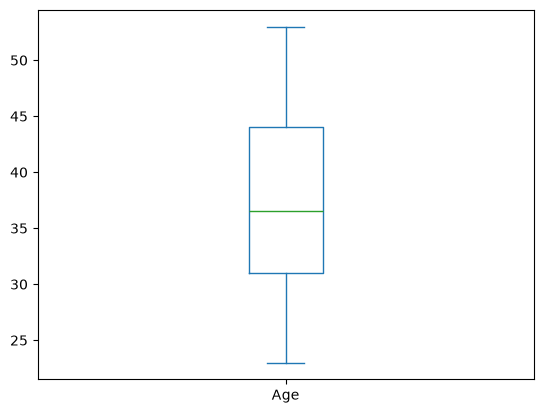

In [51]:
new_salary_data.Age.plot(kind = 'box')

# there is no outliers in age column. 

<Axes: >

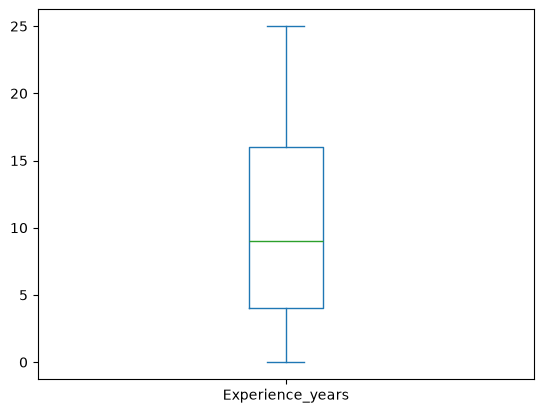

In [52]:
new_salary_data.Experience_years.plot(kind = 'box')

<Axes: >

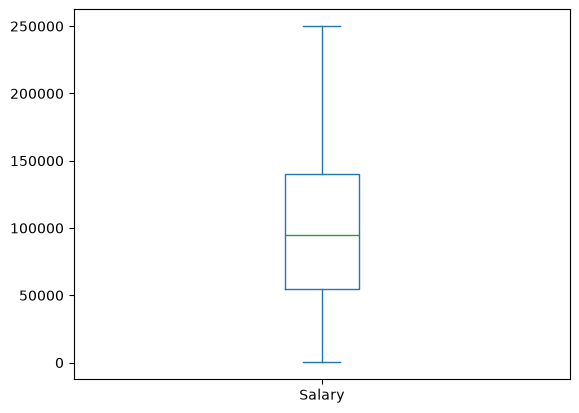

In [53]:
new_salary_data.Salary.plot(kind = 'box')

<Axes: ylabel='Frequency'>

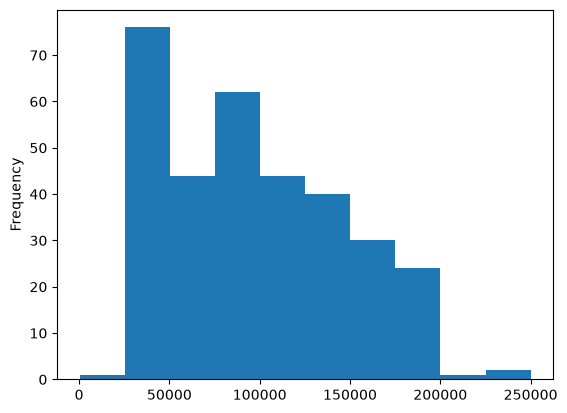

In [ ]:
new_salary_data.Salary.plot(kind='hist')

# 70+ candidates have more than 50000+ salary

### Feature Engineering 
- Since algo do not understand text so convert it into numbers

Label Encoding

In [57]:
from sklearn.preprocessing import LabelEncoder
Label_Encoder = LabelEncoder()


In [58]:
new_salary_data['Gender_Encode'] = Label_Encoder.fit_transform(new_salary_data['Gender'])


In [59]:
new_salary_data['Degree_Encode'] = Label_Encoder.fit_transform(new_salary_data['Degree'])


In [66]:
new_salary_data['Job_Title_Encode'] = Label_Encoder.fit_transform(new_salary_data['Job_title'])


In [68]:
new_salary_data.head()

,Age,Gender,Degree,Job_title,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_title_Encode,Job_Title_Encode
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,159
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,17
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,130
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,101
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,22


### Feature Scaling
- Age and experience are in different scale and min and max values are different in both

In [69]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [72]:
new_salary_data['Age_scaled'] = std_scaler.fit_transform(new_salary_data[['Age']])
new_salary_data['Experience_years_scaled'] = std_scaler.fit_transform(new_salary_data[['Experience_years']])


In [73]:
# data after scaling
new_salary_data.head()

,Age,Gender,Degree,Job_title,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_title_Encode,Job_Title_Encode,Age_scaled,Experience_years_scaled
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,159,-0.750231,-0.761821
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,17,-1.307742,-1.063017
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,130,1.061680,0.744158
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,101,-0.192720,-0.460625
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,22,2.037324,1.497148


### Dependent and independent feature

In [75]:
# Independent variable
X = new_salary_data[['Age_scaled', 'Gender_Encode', 'Degree_Encode', 'Job_Title_Encode', 'Experience_years_scaled']]

# dependent variable
y = new_salary_data['Salary']  

In [76]:
X.head()

,Age_scaled,Gender_Encode,Degree_Encode,Job_Title_Encode,Experience_years_scaled
0,-0.750231,1,0,159,-0.761821
1,-1.307742,0,1,17,-1.063017
2,1.061680,1,2,130,0.744158
3,-0.192720,0,0,101,-0.460625
4,2.037324,1,1,22,1.497148


In [79]:
y

0       90000.0
1       65000.0
2      150000.0
3       60000.0
4      200000.0
         ...   
348     35000.0
349    110000.0
350    160000.0
351     55000.0
371    170000.0
Name: Salary, Length: 324, dtype: float64

### Training and test data splitting

In [80]:
from sklearn.model_selection import train_test_split


In [81]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
# 80# = training data

In [90]:
x_train.shape, y_train.shape  # 80%tage of data

((259, 5), (259,))

In [91]:
x_test.shape, x_test.shape # 20%tage of data

((65, 5), (65, 5))

### Developing the model

In [92]:
from sklearn.linear_model import LinearRegression
Linear_regeression_model = LinearRegression()


In [93]:
# Training the model on training data
Linear_regeression_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[20181.89, 7389.08,15422.74, 19.58,19204.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age_scaled','Gender_Encode','Degree_Encode','Job_Title_Encode', 'Experience_years_scaled']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.6e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [97]:
# Model prediction
y_pred_lr = Linear_regeression_model.predict(x_test)
y_pred_lr

array([117415.91344602, 125562.80742758,  48965.15386167, 128739.34887988,
       106828.49930535,  99654.76748821,  49101.27883652,  57130.71108104,
       166333.69009266,  43112.61060113,  40544.18249367, 122553.217185  ,
       107631.15450848, 155580.48335296,  83652.23602446, 170890.28450907,
        98984.50106226, 109338.33008328,  42267.86835535,  48089.87647812,
        75674.93528581,  64499.29874156,  63619.2494321 ,  31543.41552147,
       188376.92844437,  90340.76921722, 155285.91529198, 160863.57809872,
       185183.73163709,  34741.26224478, 124850.6230462 , 165106.94121635,
        87085.00622186, 155425.69514031, 149190.25441885,  45729.74800187,
        88475.39474629,  92025.62668073,  97997.32557607,  40411.112659  ,
        89995.79796521,  53873.21977084, 108677.48549927,  54590.96778663,
        36497.92729223,  48611.85493217, 129193.72126941,  43102.58902589,
       162383.16672117,  81874.95829259, 157771.0301154 ,  43984.89040816,
        59950.21740617,  

In [99]:
df = pd.DataFrame({'y_Actual' :y_test, 'y_Predicted': y_pred_lr })
df

,y_Actual,y_Predicted
132,100000.0,117415.913446
108,100000.0,125562.807428
137,50000.0,48965.153862
9,110000.0,128739.348880
181,105000.0,106828.499305
...,...,...
104,80000.0,117279.788471
233,85000.0,83396.821876
60,170000.0,177743.761029
94,75000.0,72275.144274


In [101]:
df['Error'] = df['y_Actual'] - df['y_Predicted']
df

,y_Actual,y_Predicted,Error
132,100000.0,117415.913446,-17415.913446
108,100000.0,125562.807428,-25562.807428
137,50000.0,48965.153862,1034.846138
9,110000.0,128739.348880,-18739.348880
181,105000.0,106828.499305,-1828.499305
...,...,...,...
104,80000.0,117279.788471,-37279.788471
233,85000.0,83396.821876,1603.178124
60,170000.0,177743.761029,-7743.761029
94,75000.0,72275.144274,2724.855726


In [102]:
# but these errors should be absolute
df['abs_error'] = abs(df['Error'])
df


,y_Actual,y_Predicted,Error,abs_error
132,100000.0,117415.913446,-17415.913446,17415.913446
108,100000.0,125562.807428,-25562.807428,25562.807428
137,50000.0,48965.153862,1034.846138,1034.846138
9,110000.0,128739.348880,-18739.348880,18739.348880
181,105000.0,106828.499305,-1828.499305,1828.499305
...,...,...,...,...
104,80000.0,117279.788471,-37279.788471,37279.788471
233,85000.0,83396.821876,1603.178124,1603.178124
60,170000.0,177743.761029,-7743.761029,7743.761029
94,75000.0,72275.144274,2724.855726,2724.855726


In [103]:
Mean_absolute_Error = df['abs_error'].mean()
Mean_absolute_Error

np.float64(10570.78640113616)

### Model Evaluation

In [104]:
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [105]:
r2_score(y_test, y_pred_lr)


0.8911231066517091

In [106]:
print(f'Accuracy of the model = {round(r2_score(y_test, y_pred_lr),4)*100} %')


Accuracy of the model = 89.11 %


In [107]:
# MAE
round(mean_absolute_error(y_test, y_pred_lr),2)
print(f"Mean Absolute Error = {round(mean_absolute_error(y_test, y_pred_lr),2)}")


Mean Absolute Error = 10570.79


In [108]:
# MSE 
mse = round(mean_squared_error(y_test, y_pred_lr),2)
mse

205754135.72

In [110]:
# RMSE
print('Root Mean Squared Error (RMSE) = ', mse**(0.5))


Root Mean Squared Error (RMSE) =  14344.132449193294


In [112]:
# Coefficient
Linear_regeression_model.coef_
# 5 independent features so 5 Coefficients

array([2.01818940e+04, 7.38907834e+03, 1.54227359e+04, 1.95769562e+01,
       1.92043082e+04])

In [113]:
# Intercepts
Linear_regeression_model.intercept_

np.float64(86001.49320553176)

### Customize Prediction

Suppose we want to predict the salary of 
* Age = 49
* Gender = 'Female' = 0
* Degree = 'PhD' = 2
* Job_Title = 'Director' = 22
* Experience_years = 15
* Salary = ?


In [ ]:
# First we need to do scaling of age and experiecne
Age1 = std_scaler.transform([[49]])
Age1

d:\AI ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[5.86448677]])

In [118]:
Experience_years1 = std_scaler.transform([[15]])
Experience_years1

d:\AI ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.74415815]])

In [119]:
Age = 5.86448677
Gender = 0
Degree = 2
Job_Title = 22
Experience_years = 0.74415815
# Find the Salary = ?


In [115]:
std_scaler.transform([[15]])


d:\AI ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.74415815]])

In [125]:
Emp_salary = Linear_regeression_model.predict([[ Age, Gender, Degree, Job_Title, Experience_years]])
Emp_salary

d:\AI ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([249925.15061728])